# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
hotels = pd.read_csv(url)

In [3]:
hotels.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. Hotel managers, revenue teams, marketing teams, and operations staff.

2. Managers want to improve profitability and occupancy, revenue teams want to optimize prices, marketing teams want to understand customers and booking channels, and operations staff want to plan staffing and resources.

3. Which booking characteristics are associated with cancellations, and how can hotels use this information to reduce cancellations/improve occupancy and revenue?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [7]:
hotels.info()
display(hotels.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            94

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,9404,9404.000000,9404.000000,9404.000000,9404,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,...,9404,7069.000000,1011.000000,9404.000000,9404,9404.000000,9404.000000,9404.000000,9404,9404
unique,1,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,713
top,Resort Hotel,NaN,NaN,NaN,October,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-11-15
freq,9404,NaN,NaN,NaN,1610,NaN,NaN,NaN,NaN,NaN,...,8816,NaN,NaN,NaN,7031,NaN,NaN,NaN,7069,124
mean,NaN,0.248299,79.326244,2015.156104,NaN,37.026584,15.515313,1.155040,3.078690,1.864738,...,NaN,200.990946,219.550940,1.019034,NaN,86.843614,0.144938,0.613143,NaN,NaN
std,NaN,0.432049,87.584146,0.443661,NaN,11.083421,9.025545,1.124304,2.379227,1.198565,...,NaN,80.330753,104.296474,10.137928,NaN,53.759940,0.353264,0.835930,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,9.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,8.000000,2015.000000,NaN,31.000000,7.000000,0.000000,1.000000,2.000000,...,NaN,156.000000,135.000000,0.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,48.000000,2015.000000,NaN,38.000000,16.000000,1.000000,3.000000,2.000000,...,NaN,240.000000,223.000000,0.000000,NaN,71.550000,0.000000,0.000000,NaN,NaN
75%,NaN,0.000000,118.000000,2015.000000,NaN,45.000000,23.000000,2.000000,5.000000,2.000000,...,NaN,241.000000,286.000000,0.000000,NaN,120.600000,0.000000,1.000000,NaN,NaN


In [8]:
display(hotels.isnull().sum())

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [9]:
print("Number of duplicate rows:", hotels.duplicated().sum())

Number of duplicate rows: 1674


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. The dataset contains missing values in a bunch of columns (like country) and has 1,674 duplicate rows.

2. I would remove the duplicate rows with "drop_duplicates()" and either fill, label, or remove missing values depending on the column.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

,adr,lead_time,is_canceled
count,9404.000000,9404.000000,9404.000000
mean,86.843614,79.326244,0.248299
std,53.759940,87.584146,0.432049
min,-6.380000,0.000000,0.000000
25%,45.000000,8.000000,0.000000
50%,71.550000,48.000000,0.000000
75%,120.600000,118.000000,0.000000
max,508.000000,737.000000,1.000000


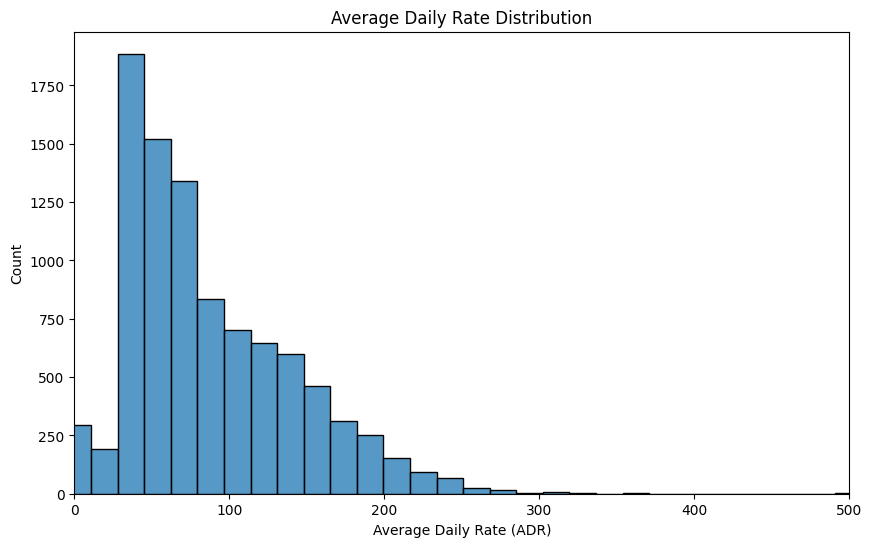

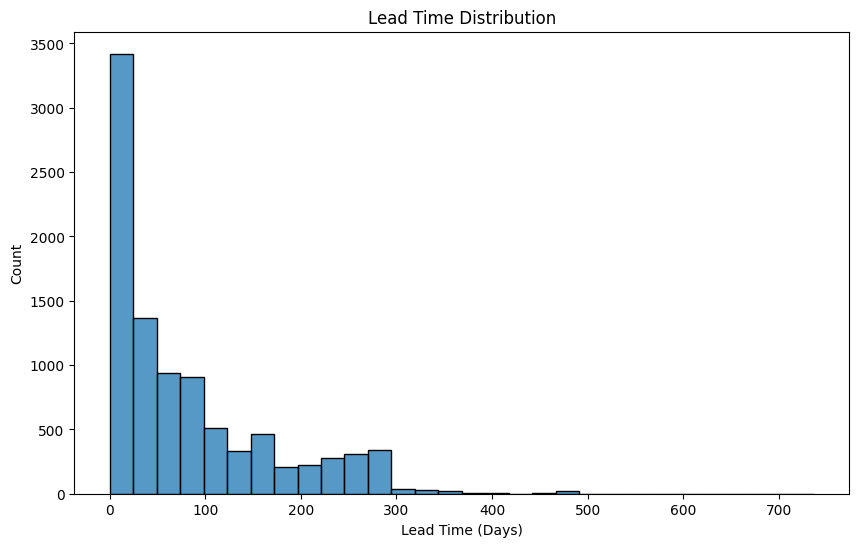

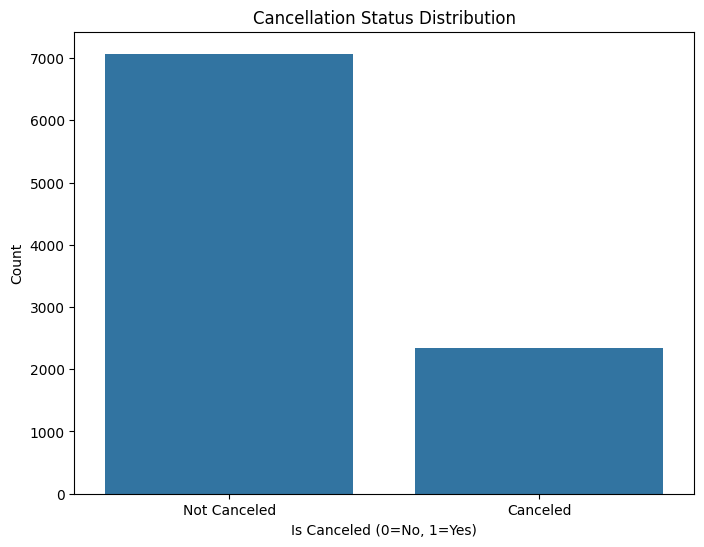

In [10]:
# Summary statistics
display(hotels[["adr", "lead_time", "is_canceled"]].describe())

# Average Daily Rate
fig1 = plt.figure(figsize=(10, 6))
sns.histplot(hotels["adr"], bins=30)
plt.title("Average Daily Rate Distribution")
plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Count")
plt.xlim(0, 500)
plt.show()

# Lead Time
fig2 = plt.figure(figsize=(10, 6))
sns.histplot(hotels["lead_time"], bins=30)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Count")
plt.show()

# Cancellations
fig3 = plt.figure(figsize=(8, 6))
sns.countplot(data=hotels, x="is_canceled")
plt.title("Cancellation Status Distribution")
plt.xlabel("Is Canceled (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  Most average daily rates are around $100, but a few high prices make the distribution right-skewed.
- **Variable 2 – Summary and insights:**  Most guests booked within a few months of arrival, while some booked much earlier.
- **Variable 3 – Summary and insights:**  Most bookings were not canceled, but about 37% were, making cancellations a business concern.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

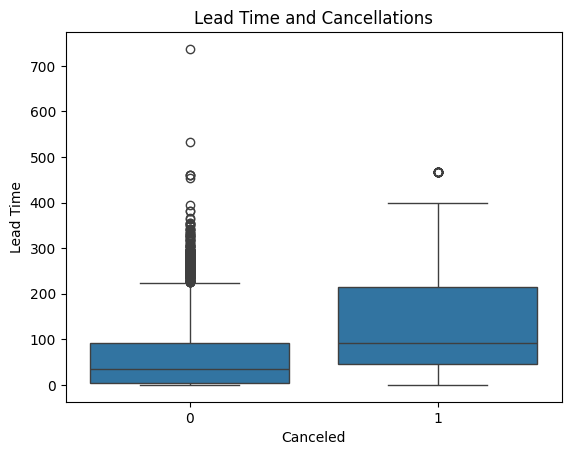

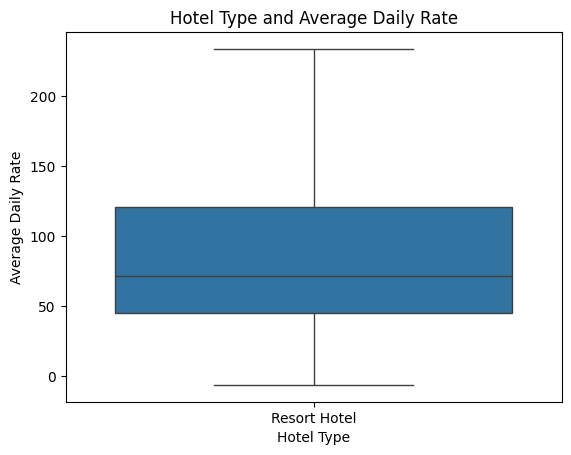

In [17]:
# Lead time compared with cancellation status
sns.boxplot(data=hotels, x="is_canceled", y="lead_time")
plt.title("Lead Time and Cancellations")
plt.xlabel("Canceled")
plt.ylabel("Lead Time")
plt.show()

# Hotel type compared with average daily rate
sns.boxplot(data=hotels, x="hotel", y="adr", showfliers=False)
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")
plt.title("Hotel Type and Average Daily Rate")
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  Canceled bookings generally had longer lead times, suggesting that guests who book farther in advance may be more likely to cancel.
- **Relationship 2:**  City hotels generally had higher daily rates than resort hotels, which could help each hotel type make better pricing decisions.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. Bookings with longer lead times were more likely to be canceled.
2. This involves variability because cancellation behavior changes depending on how far in advance a booking is made.
3. Predictive analytics could estimate whether a booking will be canceled based on lead time and other booking details, helping hotels prepare for cancellations and manage room availability.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1.
- There was a connection between longer lead times and a greater number of cancellations.
- City hotels charged higher daily rates.

2. Such patterns can assist managers with improving occupancy, pricing, and revenue planning.
3. Hotels should keep an eye on bookings that have a long lead time and send out reminders to confirm them.
4. This is in support of my learning outcome concerning the use of data to identify patterns and make business recommendations.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [18]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] Converting notebook assignment_05_eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 471659 bytes to assignment_05_eda.html
